# NETFLIX RECOMMENDATION MODEL PROJECT

Recommendation Engines are the much needed manifestations of the desired Predictability of User Activity. Recommendation Engines move one step
further and not only give information but put forth strategies to further increase users interaction with the platform.

In today's world OTT platform and Streaming Services have taken up a big chunk in the Retail and Entertainment industry. Organizations like Netflix, Amazon etc. analyse User Activity Pattern's and suggest products that better suit the user needs and choices.

For the purpose of this Project we will be
creating one such Recommendation Engine
from the ground-up, where every single user,
based on there area of interest and ratings,
would be recommended a list of movies that
are best suited for them.

1. Find out the list of most popular and liked genre
2. Create Model that finds the best suited Movie for one
user in every genre.
3. Find what Genre Movies have received the best and
worst ratings based on User Rating.

## Loading Dataset and Pre-proccessing (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise.model_selection import cross_validate
import random
from surprise import Reader, Dataset, SVD

In [4]:
df = pd.read_csv('/content/combined_data_1.txt.zip', header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
df.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [5]:
df.dtypes

,0
Cust_Id,object
Rating,float64


In [6]:
df.isnull().sum()

,0
Cust_Id,0
Rating,4499


In [7]:
movie=df.isnull().sum()
movie=movie["Rating"]
movie

4499

In [8]:
customer=df['Cust_Id'].nunique()
customer

475257

In [9]:
rating=df['Cust_Id'].count()-movie
rating

24053764

In [10]:
stars=df.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


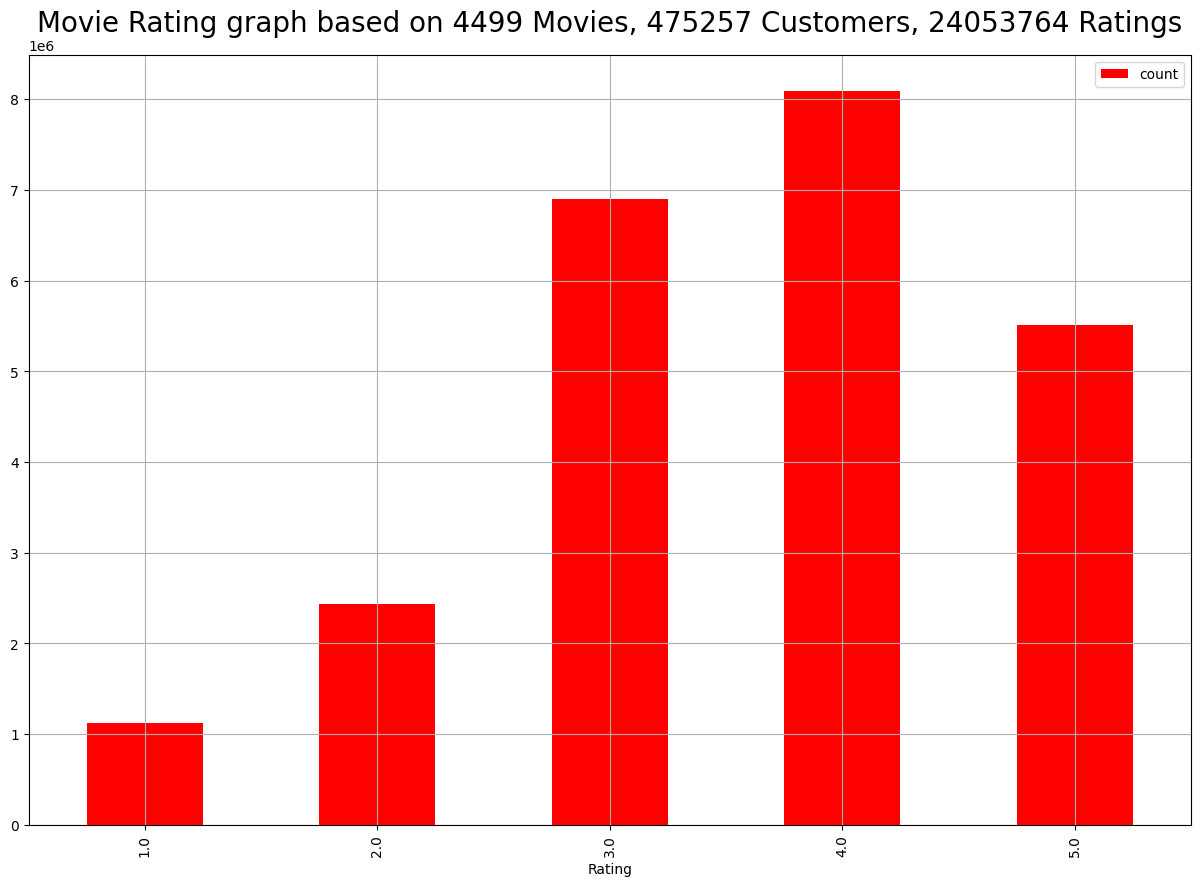

In [11]:
graph=stars.plot(kind='bar', figsize=(15,10), color='r')
plt.title(f'Movie Rating graph based on {movie} Movies, {customer} Customers, {rating} Ratings', fontsize=20)
plt.grid(True)

In [12]:
movie_id=None
movie_np = []
for cust_id in df['Cust_Id']:
    if ':' in cust_id:
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)
df['Movie_Id'] = movie_np
df = df[df['Rating'].notna()]
df.head()

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [14]:
df["Cust_Id"]=df["Cust_Id"].astype(int)

In [15]:
dfm=df.groupby('Movie_Id')['Rating'].agg(["count"])
dfm
#Removing all the users with less movies rated and also the movies with lower number of ratings

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [16]:
movie_bm=round(dfm['count'].quantile(0.6))
movie_bm

908

In [17]:
drop_movie_list=dfm[dfm['count']<movie_bm].index
drop_movie_list

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [18]:
dfc=df.groupby('Cust_Id')['Rating'].agg(["count"])
dfc

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [19]:
customer_bm=round(dfc['count'].quantile(0.6))
customer_bm

36

In [20]:
drop_customer_list=dfc[dfc['count']<customer_bm].index
drop_customer_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_Id', length=282042)

In [21]:
df=df[~df['Movie_Id'].isin(drop_movie_list)]
df=df[~df['Cust_Id'].isin(drop_customer_list)]
print('Post EDA Dataset shape: {}'.format(df.shape))

Post EDA Dataset shape: (19695836, 3)


In [22]:
df1 = pd.read_csv("/content/movie_titles.csv",  encoding='latin1',header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])
df1

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [23]:
reader=Reader()
data=Dataset.load_from_df(df[['Cust_Id','Movie_Id','Rating']][:100000], reader)
model=SVD()
cross_validate(model, data, measures=['RMSE'], cv=3)

{'test_rmse': array([1.01865231, 1.01833665, 1.02165431]),
 'fit_time': (5.638922452926636, 1.8656961917877197, 1.4710216522216797),
 'test_time': (0.5497667789459229, 0.17098474502563477, 0.16463088989257812)}

In [24]:
genres_list = ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi', 'Romance', 'Documentary', 'Thriller']

# Generate a random choice for each movie title
random_genres = np.random.choice(genres_list, size=len(df1))

df1['Genre'] = random_genres

In [25]:
print("Check Randomness")
print(df1[['Movie_Id', 'Name', 'Genre']].head(15))

Check Randomness
    Movie_Id                                               Name     Genre
0          1                                    Dinosaur Planet    Comedy
1          2                         Isle of Man TT 2004 Review     Drama
2          3                                          Character    Action
3          4                       Paula Abdul's Get Up & Dance    Sci-Fi
4          5                           The Rise and Fall of ECW    Sci-Fi
5          6                                               Sick   Romance
6          7                                              8 Man   Romance
7          8                         What the #$*! Do We Know!?   Romance
8          9                           Class of Nuke 'Em High 2   Romance
9         10                                            Fighter    Comedy
10        11                     Full Frame: Documentary Shorts     Drama
11        12                               My Favorite Brunette    Action
12        13  Lord of

In [26]:
print("Genre Distribution Counts ")
print(df1['Genre'].value_counts())

Genre Distribution Counts 
Genre
Drama          2274
Comedy         2273
Romance        2232
Sci-Fi         2230
Action         2211
Documentary    2210
Thriller       2199
Horror         2141
Name: count, dtype: int64


In [27]:
df_movie_stats = df.groupby('Movie_Id')['Rating'].agg(['count', 'mean']).reset_index()
df_movie_stats.columns = ['Movie_Id', 'Vote_Count', 'Avg_Rating']

In [28]:
df_analysis = df_movie_stats.merge(df1, on='Movie_Id', how='inner')

In [29]:
genre_metrics = df_analysis.groupby('Genre').agg({
    'Vote_Count': 'sum',      # Total votes (Popularity)
    'Avg_Rating': 'mean'      # Average rating (Quality)
}).reset_index()

## Objective 1

Find out the list of most popular and liked genre

In [30]:
print("\n--- OBJECTIVE 1: Most Popular Genres (by Total Votes) ---")
most_popular = genre_metrics.sort_values(by='Vote_Count', ascending=False)
print(most_popular)


--- OBJECTIVE 1: Most Popular Genres (by Total Votes) ---
         Genre  Vote_Count  Avg_Rating
7     Thriller     2878066    3.479261
6       Sci-Fi     2830249    3.480900
5      Romance     2573143    3.500377
1       Comedy     2536930    3.459201
3        Drama     2371192    3.455383
2  Documentary     2338537    3.429784
0       Action     2087614    3.438018
4       Horror     2080105    3.482530


## Objective 2

Create Model that finds the best suited Movie for one
user in every genre

In [34]:
# The full dataset (24M rows) causes a memory crash, we take a random sample of 100,000 ratings to train the model efficiently
SAMPLE_SIZE = 100000
reader = Reader()

df_sample = df[['Cust_Id', 'Movie_Id', 'Rating']].sample(n=SAMPLE_SIZE, random_state=42)

data = Dataset.load_from_df(df_sample, reader)
trainset = data.build_full_trainset()

In [35]:
print(f"Training SVD model on {SAMPLE_SIZE} ratings...")
model = SVD()
model.fit(trainset)
print("Model training complete!")

Training SVD model on 100000 ratings...
Model training complete!


In [37]:
# Select a target user, example USER 7
target_user_id = df['Cust_Id'].unique()[7]
print(f"Generating recommendations for User ID: {target_user_id}")

Generating recommendations for User ID: 1644750


In [38]:
all_movie_ids = df1['Movie_Id'].unique()
user_seen_ids = df[df['Cust_Id'] == target_user_id]['Movie_Id'].unique()

movies_to_predict = list(set(all_movie_ids) - set(user_seen_ids))

In [39]:
predictions = []
for movie_id in movies_to_predict:
    # Predict the rating
    pred = model.predict(target_user_id, movie_id)
    predictions.append([movie_id, pred.est])

pred_df = pd.DataFrame(predictions, columns=['Movie_Id', 'Predicted_Rating'])

In [40]:
final_recs = pred_df.merge(df1[['Movie_Id', 'Name', 'Genre']], on='Movie_Id', how='left')

In [41]:
best_indices = final_recs.groupby('Genre')['Predicted_Rating'].idxmax()
best_in_every_genre = final_recs.loc[best_indices].sort_values(by='Predicted_Rating', ascending=False)

In [43]:
print("Best Suited Movie for User in Every Genre")
print(best_in_every_genre[['Genre', 'Name', 'Predicted_Rating']])

Best Suited Movie for User in Every Genre
            Genre                                   Name  Predicted_Rating
3251       Sci-Fi  Family Guy: Freakin' Sweet Collection          4.602540
1994        Drama                 The Simpsons: Season 6          4.553676
3261       Action                         Lost: Season 1          4.512631
1420      Romance                        Alias: Season 1          4.471988
2878  Documentary      The Simpsons: Treehouse of Horror          4.462828
2006     Thriller                                Firefly          4.372787
2427       Horror                Stargate SG-1: Season 8          4.335151
1912       Comedy                       Samurai Champloo          4.284063


## Objective 3

Find what Genre Movies have received the best and
worst ratings based on User Rating

In [44]:
print("\n--- OBJECTIVE 3: Best Rated Genres ---")
best_rated = genre_metrics.sort_values(by='Avg_Rating', ascending=False)
print(best_rated.head())

print("\n--- OBJECTIVE 3: Worst Rated Genres ---")
print(best_rated.tail())


--- OBJECTIVE 3: Best Rated Genres ---
      Genre  Vote_Count  Avg_Rating
5   Romance     2573143    3.500377
4    Horror     2080105    3.482530
6    Sci-Fi     2830249    3.480900
7  Thriller     2878066    3.479261
1    Comedy     2536930    3.459201

--- OBJECTIVE 3: Worst Rated Genres ---
         Genre  Vote_Count  Avg_Rating
7     Thriller     2878066    3.479261
1       Comedy     2536930    3.459201
3        Drama     2371192    3.455383
0       Action     2087614    3.438018
2  Documentary     2338537    3.429784


/tmp/ipython-input-309899542.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Vote_Count', y='Genre', data=most_popular, palette='viridis')
/tmp/ipython-input-309899542.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Rating', y='Genre', data=best_rated, palette='magma')


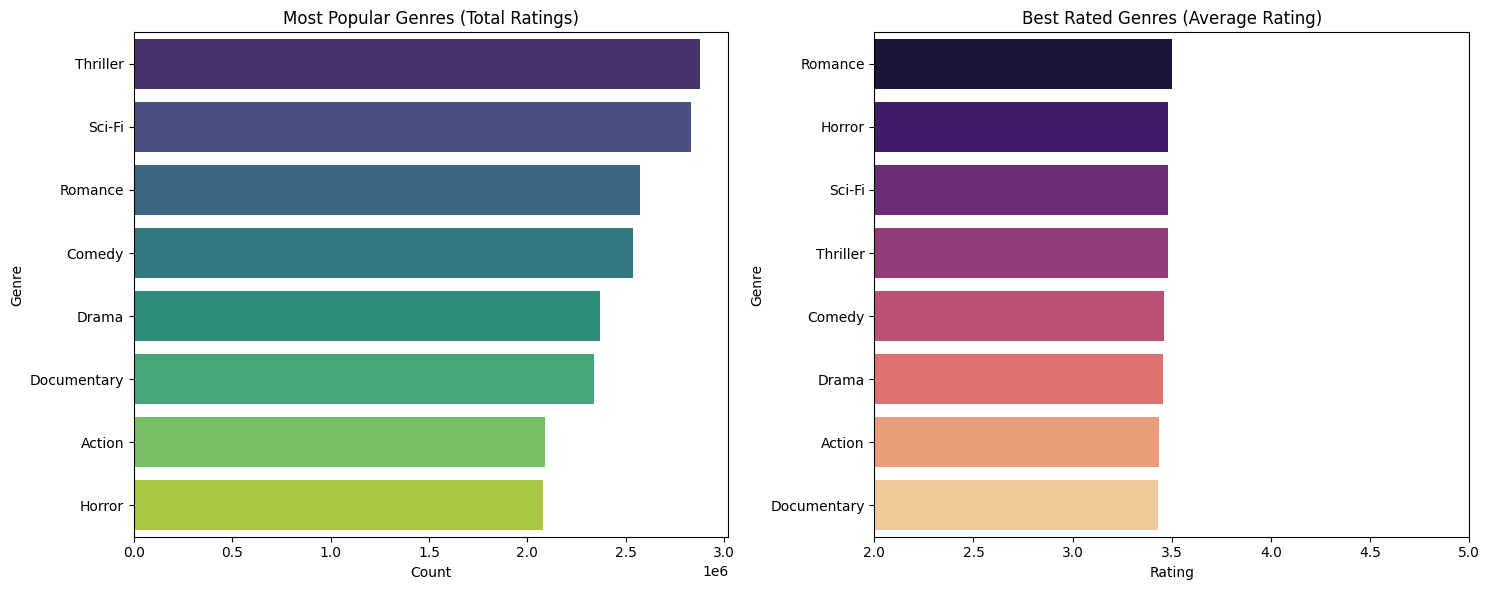

In [45]:
plt.figure(figsize=(15, 6))

# Popularity
plt.subplot(1, 2, 1)
sns.barplot(x='Vote_Count', y='Genre', data=most_popular, palette='viridis')
plt.title('Most Popular Genres (Total Ratings)')
plt.xlabel('Count')

# Ratings
plt.subplot(1, 2, 2)
sns.barplot(x='Avg_Rating', y='Genre', data=best_rated, palette='magma')
plt.title('Best Rated Genres (Average Rating)')
plt.xlim(2, 5)
plt.xlabel('Rating')

plt.tight_layout()
plt.show()